In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import simweights
import pickle
import os, sys
import re
import numpy as np
import matplotlib as mat
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import pandas as pd
import tables
import h5py
import math
from scipy.stats import mstats
import matplotlib as mpl
import matplotlib.font_manager as font_manager


In [3]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/notebooks/weighting")
from weights import *
from utils import *
from selections import selection_mask
from fonts import *
from plot_utils import *

In [4]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/bdt/notebooks/")

from bdt import *
from models import *

In [5]:
# Append the custom module path
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing")

simulation_datasets = {}

from datasets import datasets_analysis as datasets
reco_versions = ["taureco_iceprod_v4"]
for reco_version in reco_versions: simulation_datasets[reco_version] = getattr(datasets, reco_version)

In [6]:
livetime_yr = 11.687
livetime_s  = livetime_yr * 365.25 * 24 * 3600 # 11.687 year

In [7]:
plotting_path = f"/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/hese_taureco_iceprod/study_selections"
os.system(f"mkdir -p {plotting_path}")

0

In [8]:
# weight functions
spline_file = '/data/ana/Diffuse/NNMFit/MCEq_splines/v1.2.1/MCEq_splines_PRI-Gaisser-H4a_INT-SIBYLL23c_allfluxes.pickle'

# conventional            
flux_keys_conv =  ['conv_antinumu','conv_numu','conv_antinue','conv_nue','conv_antinutau','conv_nutau']
spline_object_conv = SplineHandler(spline_file, flux_keys_conv)
conv_flux = spline_object_conv.return_weight
generator_conv = lambda pdgid, energy, cos_zen: conv_flux(pdgid, energy, cos_zen)

# prompt
flux_keys_pr =  ['pr_antinumu','pr_numu','pr_antinue','pr_nue','pr_antinutau','pr_nutau']
spline_object_pr = SplineHandler(spline_file, flux_keys_pr)
pr_flux = spline_object_pr.return_weight
generator_pr = lambda pdgid, energy, cos_zen: pr_flux(pdgid, energy, cos_zen)

# astro
gamma_astro = 2.87
per_flavor_norm = 2.12
def AstroFluxModel(pdgid, energy, cos_zen):
    flux = 0.5*(per_flavor_norm*1e-18)*(energy/1e5)**-gamma_astro
    return flux

In [9]:
def open_datasets( simulation_dataset, keys_to_merge ):

    # open the files
    for key in simulation_dataset:
        print(f"----- Extracting files for {key}")
        simulation_dataset[key]['hdf_file'] = pd.HDFStore(simulation_dataset[key]['hdf_file_path'],'r')
        if "Muon" in key: simulation_dataset[key]['weighter'] = None
        else: simulation_dataset[key]['weighter'] = simweights.NuGenWeighter( simulation_dataset[key]['hdf_file'] ,nfiles=simulation_dataset[key]['nfiles'])

    # merging files
    for new_key in keys_to_merge:
        print(f"----- Creating new key {new_key}")
        simulation_dataset[new_key] = {}
        simulation_dataset[new_key]['variables'] = {}
        simulation_dataset[new_key]['weighter'] = None

        for key in keys_to_merge[new_key]:
            
            print(f"Using {key}")
            # merge the weighters
            if simulation_dataset[new_key]['weighter'] == None:
                simulation_dataset[new_key]['weighter'] = simulation_dataset[key]['weighter']
            else: simulation_dataset[new_key]['weighter'] += simulation_dataset[key]['weighter']

    # # calculate weights
    # for key in simulation_dataset:
    #     simulation_dataset[key]['weights_astro'] = simulation_dataset[key]["weighter"].get_weights(AstroFluxModel) * livetime_s
    #     simulation_dataset[key]['weights_conv'] = simulation_dataset[key]["weighter"].get_weights(generator_conv) * livetime_s
    #     simulation_dataset[key]['weights_pr'] = simulation_dataset[key]["weighter"].get_weights(generator_pr) * livetime_s


    return simulation_dataset



In [10]:
keys_to_merge = {}

keys_to_merge["taureco_iceprod_v4"] = {
    "NuE" : ["NuE_midE", "NuE_highE"],
    "NuMu" : ["NuMu_midE", "NuMu_highE"],
    "NuTau" : ["NuTau_midE", "NuTau_highE"],
    "NuAll" : ['NuE', "NuMu", "NuTau"],
}


In [11]:
for key in simulation_datasets: simulation_datasets[key] = open_datasets( simulation_datasets[key], keys_to_merge[key] )

----- Extracting files for MuonGun
----- Extracting files for NuE_highE
----- Extracting files for NuE_midE
----- Extracting files for NuTau_midE
----- Extracting files for NuTau_highE
----- Extracting files for NuMu_highE
----- Extracting files for NuMu_midE
----- Creating new key NuE
Using NuE_midE
Using NuE_highE
----- Creating new key NuMu
Using NuMu_midE
Using NuMu_highE
----- Creating new key NuTau
Using NuTau_midE
Using NuTau_highE
----- Creating new key NuAll
Using NuE
Using NuMu
Using NuTau


In [12]:
dataset_label_dict = {
    "taureco_iceprod_v4" : "iceprod",
}

check if merging works now, seems to be fine

In [13]:
def nan_to_zero(values):
    return np.array([0 if (isinstance(v, float) and math.isnan(v)) else v for v in values])

In [14]:
data = {}

for key in simulation_datasets:

    simulation_dataset = simulation_datasets[key]

    channel_data = {}

    for flavor in ['NuE', "NuMu", "NuTau"]:
        weights = simulation_dataset[flavor]["weighter"].get_weights(AstroFluxModel) * livetime_s
        rate = np.sum(weights)
        error = np.sqrt(np.sum(weights**2))
        channel_data[f"astro_{flavor}"] = f"{rate:.2f} ± {error:.2f}"

    # Muon
    channel_data["MuonWeightConv"] = sum( nan_to_zero( simulation_datasets[key]["MuonGun"]["hdf_file"]["MuonWeightConv"]["value"]))*livetime_s
    channel_data["MuonWeightConv*2.1"] = sum( nan_to_zero( simulation_datasets[key]["MuonGun"]["hdf_file"]["MuonWeightScaled"]["value"]))*livetime_s
    channel_data["MuonWeightPrompt"] = sum( nan_to_zero( simulation_datasets[key]["MuonGun"]["hdf_file"]["MuonWeightPrompt"]["value"]))*livetime_s

    # Conventional
    flavor = "NuAll"
    ConventionalAtmosphericPassingFractions = simulation_dataset[flavor]["weighter"].get_column("ConventionalAtmosphericPassingFractions", "value")
    weights_conv = simulation_dataset[flavor]["weighter"].get_weights(generator_conv) * livetime_s * ConventionalAtmosphericPassingFractions
    rate_conv = np.sum(weights_conv)
    err_conv = np.sqrt(np.sum(weights_conv**2))
    channel_data["conv"] = f"{rate_conv:.3f} ± {err_conv:.3f}"

    # Prompt
    PromptAtmosphericPassingFractions = simulation_dataset[flavor]["weighter"].get_column("PromptAtmosphericPassingFractions", "value")
    weights_prompt = simulation_dataset[flavor]["weighter"].get_weights(generator_pr) * livetime_s * PromptAtmosphericPassingFractions
    rate_prompt = np.sum(weights_prompt)
    err_prompt = np.sqrt(np.sum(weights_prompt**2))
    channel_data["prompt"] = f"{rate_prompt:.2f} ± {err_prompt:.2f}"

    data[ dataset_label_dict[key] ] = channel_data

# Create DataFrame
df = pd.DataFrame.from_dict(data, orient='index')

# Optional: specify column order
# columns_order = [f"astro_{flavor}" for flavor in ['NuE', 'NuMu', 'NuTau']] + ["conv", "prompt"]
# df = df[columns_order]

# Display as string table
print(df.to_string())

            astro_NuE    astro_NuMu   astro_NuTau  MuonWeightConv  MuonWeightConv*2.1  MuonWeightPrompt            conv       prompt
iceprod  56.75 ± 0.37  20.58 ± 0.15  35.04 ± 0.28        9.173204           19.263728         27.479174  25.828 ± 0.644  7.03 ± 0.06


In [15]:
# load bdt models
import joblib

loaded_models = {
    name: {
        "model1": joblib.load(info["model1"]),
        "model2": joblib.load(info["model2"])
    }
    for name, info in models.items()
}

/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/cvmfs/icecube.opensciencegrid.org/py3-v4.4.1/RHEL_7_x86_64_v2/lib/python3.12/pickle.py:1753: UserWarning: [06:32:49] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling


In [16]:
def append_bdt_scores(simulation_dataset, model_pair):
    for flavor in ["NuE", "NuMu", "NuTau", "NuAll"]:
        weighter = simulation_dataset[flavor]["weighter"]
        bdt1, bdt2 = Append_BDT(weighter, model_pair["model1"], model_pair["model2"])
        # Attach as new columns
        simulation_dataset[flavor]["bdt_scores1"] = bdt1
        simulation_dataset[flavor]["bdt_scores2"] = bdt2
    
    bdt1,bdt2 = Append_BDT_muon( simulation_dataset["MuonGun"]["hdf_file"], model_pair["model1"], model_pair["model2"] )
    simulation_dataset["MuonGun"]["bdt_scores1"] = bdt1
    simulation_dataset["MuonGun"]["bdt_scores2"] = bdt2

In [17]:
# plot bdt score
# simulation_dataset_name = "evtgen_v2_rec_v5"
colors = ["C0","C3","C2", "black"]

def plot_bdt_score( simulation_dataset,
                    model_name,
                    cut_bdt1,
                    cut_bdt2,
                    energy_cut_threshold=None,
                    save_output = "test" ):

    model_pair = loaded_models[model_name]
    append_bdt_scores(simulation_dataset, model_pair)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    bins = np.linspace(0,1,20)

    for i,flavor in enumerate(["NuE","NuMu", "NuTau","MuonGun"]):

        if "Nu" in flavor:
            RecoETot = simulation_dataset[flavor]["weighter"].get_column("RecoETot", "value")
            weights = simulation_dataset[flavor]["weighter"].get_weights(AstroFluxModel) * livetime_s
        else: 
            weights = nan_to_zero( simulation_datasets[key][flavor]["hdf_file"]["MuonWeightScaled"]["value"])*livetime_s
            RecoETot = simulation_datasets[key]["MuonGun"]["hdf_file"]["RecoETot"]["value"]

        classification_variables = {
            "bdt_scores1" : simulation_dataset[flavor]["bdt_scores1"],
            "bdt_scores2" : simulation_dataset[flavor]["bdt_scores2"]
        }

        if energy_cut_threshold:
            mask = RecoETot > energy_cut_threshold
        else:
            mask = np.ones_like(RecoETot, dtype=bool)
            
        # bdt score 1
        ax1.hist(classification_variables["bdt_scores1"][mask], weights=weights[mask], 
                 bins=bins, histtype="step", color=colors[i], linestyle="-",label = flavor)

        mask &= classification_variables["bdt_scores1"] > cut_bdt1

        # Upper plot: histograms
        ax2.hist(classification_variables["bdt_scores2"][mask], weights=weights[mask], 
                 bins=bins, histtype="step", color=colors[i], linestyle="-",label = flavor)

    fig.suptitle(rf"Model name: {model_name}, cut_bdt1: {cut_bdt1:.2f}, cut_bdt2: {cut_bdt2:.2f}", fontsize=16)

    ax1.set_yscale('log')
    ax1.set_ylabel(f'Rate / {livetime_yr:.2f} yr')
    ax1.set_xlabel('BDT score 1')
    ax1.legend()
    ax1.grid(True)
    ax1.axvline(x = cut_bdt1,color='black', linestyle='--', linewidth=2)

    ax2.set_yscale('log')
    ax2.set_ylabel(f'Rate / {livetime_yr:.2f} yr')
    ax2.set_xlabel('BDT score 2')
    ax2.legend()
    ax2.grid(True)
    ax2.axvline(x = cut_bdt2,color='black', linestyle='--', linewidth=2)
    if save_output:
        plt.savefig(save_output)



In [18]:
classifications = {}

classifications["FinalTopology"] = {
    "variables" : ["FinalTopology"],
    "cut_functions" : {
        "Cascade" : lambda vars: vars["FinalTopology"] == 1,            
        "Double"  : lambda vars: vars["FinalTopology"] == 2,           
        "Track"   : lambda vars: vars["FinalTopology"] == 3,
    }
}

classifications["bdt_zheyang_best"] = {
    "variables" : ["bdt_scores1", "bdt_scores2"],
    "cut_functions" : {
        "Cascade" : lambda vars:  vars["bdt_scores1"] < 0.28,            
        "Double"  : lambda vars: (vars["bdt_scores1"] > 0.28) & (vars["bdt_scores2"] > 0.59),      
        "Track"   : lambda vars: (vars["bdt_scores1"] > 0.28) & (vars["bdt_scores2"] < 0.59),
    }
}

def create_bdt_classification( cut_bdt1, cut_bdt2 ):

    return {
    "variables" : ["bdt_scores1", "bdt_scores2"],
        "cut_functions" : {
            "Cascade" : lambda vars:  vars["bdt_scores1"] < cut_bdt1,            
            "Double"  : lambda vars: (vars["bdt_scores1"] > cut_bdt1) & (vars["bdt_scores2"] > cut_bdt2),      
            "Track"   : lambda vars: (vars["bdt_scores1"] > cut_bdt1) & (vars["bdt_scores2"] < cut_bdt2),
        }
    }

def create_bdt_classification_length( cut_bdt1, cut_bdt2, cut_length ):

    return {
    "variables" : ["bdt_scores1", "bdt_scores2", "RecoL"],
        "cut_functions" : {
            "Cascade" : lambda vars: (vars["bdt_scores1"] < cut_bdt1) | ( (vars["bdt_scores1"] > cut_bdt1) & (vars["bdt_scores2"] > cut_bdt2) & (vars["RecoL"] < cut_length) ),            
            "Double"  : lambda vars: (vars["bdt_scores1"] > cut_bdt1) & (vars["bdt_scores2"] > cut_bdt2) & (vars["RecoL"] > cut_length),      
            "Track"   : lambda vars: (vars["bdt_scores1"] > cut_bdt1) & (vars["bdt_scores2"] < cut_bdt2),
        }
    }

In [19]:
def analyze_classification_rates_with_cut(
    simulation_dataset, 
    classification, 
    model_name=None,
    energy_cut_threshold=None,
    print_output=True,
    save_output=None,
):
    # Assumes the following are defined globally:
    # - AstroFluxModel
    # - generator_conv
    # - generator_pr
    # - livetime_s

    # append bdt scores
    if model_name:
        model_pair = loaded_models[model_name]
        append_bdt_scores(simulation_dataset, model_pair)

    def get_total_rates():
        total = {}
        for flavor in ['NuE', 'NuMu', 'NuTau']:
            weights = simulation_dataset[flavor]["weighter"].get_weights(AstroFluxModel) * livetime_s
            if energy_cut_threshold:
                RecoETot = simulation_dataset[flavor]["weighter"].get_column("RecoETot", "value")
                mask = RecoETot > energy_cut_threshold
                weights = weights[mask]
            total[flavor] = np.sum(weights)
        
        # muons
        flavor = "MuonGun"
        weights = nan_to_zero( simulation_datasets[key][flavor]["hdf_file"]["MuonWeightScaled"]["value"])*livetime_s
        if energy_cut_threshold:
            RecoETot = simulation_datasets[key]["MuonGun"]["hdf_file"]["RecoETot"]["value"]
            mask = RecoETot > energy_cut_threshold
            weights = weights[mask]
        total[flavor] = np.sum(weights)

        return total

    total_rates = get_total_rates()

    data = {}
    purity = {}
    efficiency = {}
    significance = {}

    for ch in classification["cut_functions"]:
        channel_data = {}
        rates = {"total": 0}

        # Conventional + Prompt (NuAll)
        flavor_all = "NuAll"
        ConventionalAtmosphericPassingFractions = simulation_dataset[flavor_all]["weighter"].get_column("ConventionalAtmosphericPassingFractions", "value")
        PromptAtmosphericPassingFractions = simulation_dataset[flavor_all]["weighter"].get_column("PromptAtmosphericPassingFractions", "value")            
        RecoETot = simulation_dataset[flavor_all]["weighter"].get_column("RecoETot", "value")

        classification_variables = {}

        for var in classification["variables"]:
            if var in ["bdt_scores1", "bdt_scores2"]:
                classification_variables[var] = simulation_dataset[flavor_all][var]
            else:
                classification_variables[var] = simulation_dataset[flavor_all]["weighter"].get_column(var, "value")

        # Apply the cut function, passing the variables dict
        mask = classification["cut_functions"][ch](classification_variables)

        if energy_cut_threshold:
            mask &= RecoETot > energy_cut_threshold

        weights_conv = simulation_dataset[flavor_all]["weighter"].get_weights(generator_conv) * livetime_s * ConventionalAtmosphericPassingFractions
        rate_conv = np.sum(weights_conv[mask])
        err_conv = np.sqrt(np.sum(weights_conv[mask]**2))
        channel_data["Conventional"] = f"{rate_conv:.2f} ± {err_conv:.2f}"
        rates["total"] += rate_conv

        weights_prompt = simulation_dataset[flavor_all]["weighter"].get_weights(generator_pr) * livetime_s * PromptAtmosphericPassingFractions
        rate_prompt = np.sum(weights_prompt[mask])
        err_prompt = np.sqrt(np.sum(weights_prompt[mask]**2))
        channel_data["Prompt"] = f"{rate_prompt:.2f} ± {err_prompt:.2f}"
        rates["total"] += rate_prompt

        ###
        ### muon
        ###
        flavor = "MuonGun"
        RecoETot = simulation_datasets[key][flavor]["hdf_file"]["RecoETot"]["value"]

        classification_variables = {}

        for var in classification["variables"]:
            if var in ["bdt_scores1", "bdt_scores2"]:
                classification_variables[var] = simulation_dataset[flavor][var]
            else:
                classification_variables[var] = simulation_dataset[flavor]["hdf_file"][var]["value"]

        # Apply the cut function, passing the variables dict
        mask = classification["cut_functions"][ch](classification_variables)

        if energy_cut_threshold:
            mask &= RecoETot > energy_cut_threshold
        
        weights = nan_to_zero( simulation_datasets[key][flavor]["hdf_file"]["MuonWeightScaled"]["value"])*livetime_s
        rate_muon = np.sum(weights[mask])
        err_muon = np.sqrt(np.sum(weights[mask]**2))
        channel_data["Muon"] = f"{rate_muon:.2f} ± {err_muon:.2f}"
        rates["total"] += rate_muon

        # Astro components
        for flavor in ['NuE', 'NuMu', 'NuTau']:
            RecoETot = simulation_dataset[flavor]["weighter"].get_column("RecoETot", "value")

            classification_variables = {}

            for var in classification["variables"]:
                if var in ["bdt_scores1", "bdt_scores2"]:
                    classification_variables[var] = simulation_dataset[flavor][var]
                else:
                    classification_variables[var] = simulation_dataset[flavor]["weighter"].get_column(var, "value")


            # Apply the cut function, passing the variables dict
            mask = classification["cut_functions"][ch](classification_variables)

            if energy_cut_threshold:
                mask &= RecoETot > energy_cut_threshold

            weights = simulation_dataset[flavor]["weighter"].get_weights(AstroFluxModel) * livetime_s
            rate = np.sum(weights[mask])
            err = np.sqrt(np.sum(weights[mask]**2))
            channel_data[f"Astro {flavor}"] = f"{rate:.2f} ± {err:.2f}"
            rates[flavor] = rate
            rates["total"] += rate

        data[ch] = channel_data

        # Purity and Efficiency
        purity[ch] = {
            f: f"{rates[f]/rates['total']:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
        }
        efficiency[ch] = {
            f: f"{rates[f]/total_rates[f]:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
        }
        significance[ch] = {
            f: f"{rates[f]/np.sqrt(rates['total']-rates[f]):.2f}" for f in ['NuE', 'NuMu', 'NuTau']
        }

    # Build DataFrames
    df = pd.DataFrame.from_dict(data, orient='index')
    column_order = [f"Astro {f}" for f in ['NuE', 'NuMu', 'NuTau']] + ["Conventional", "Prompt", "Muon"]
    df = df[column_order]

    purity_df = pd.DataFrame(purity).T.round(4)
    purity_df.columns = ['NuE', 'NuMu', 'NuTau']
    purity_df.index.name = "Class"

    efficiency_df = pd.DataFrame(efficiency).T.round(4)
    efficiency_df.columns = ['NuE', 'NuMu', 'NuTau']
    efficiency_df.index.name = "Class"

    significance_df = pd.DataFrame(significance).T.round(4)
    significance_df.columns = ['NuE', 'NuMu', 'NuTau']
    significance_df.index.name = "Class"

    if print_output:
        print("\n=== Rates ===\n")
        print(df.to_string())
        print("\n=== Purity ===\n")
        print(purity_df)
        print("\n=== Efficiency ===\n")
        print(efficiency_df)
        print("\n=== Sig / sqrt(bg) ===\n")
        print(significance_df)
        print("\n=== Rates ===\n")
        print(df.to_latex(column_format="l" + "c" * len(df.columns), escape=False))
        print("\n=== Purity ===\n")
        print(purity_df.to_latex(column_format="lccc", escape=False))
        print("\n=== Efficiency ===\n")
        print(efficiency_df.to_latex(column_format="lccc", escape=False))
        print("\n=== Sig / sqrt(bg) ===\n")
        print(significance_df.to_latex(column_format="lccc", escape=False))
    if save_output:
        os.system(f"mkdir -p {os.path.dirname(save_output)}")
        with open(save_output, "w") as f:
            f.write("\n=== Rates ===\n\n")
            f.write(df.to_string())
            f.write("\n\n=== Purity ===\n\n")
            f.write(str(purity_df))
            f.write("\n\n=== Efficiency ===\n\n")
            f.write(str(efficiency_df))
            f.write("\n\n=== Sig / sqrt(bg) ===\n\n")
            f.write(str(significance_df))
            f.write("\n\n=== Rates (LaTeX) ===\n\n")
            f.write(df.to_latex(column_format="l" + "c" * len(df.columns), escape=False))
            f.write("\n\n=== Purity (LaTeX) ===\n\n")
            f.write(purity_df.to_latex(column_format="lccc", escape=False))
            f.write("\n\n=== Efficiency (LaTeX) ===\n\n")
            f.write(efficiency_df.to_latex(column_format="lccc", escape=False))
            f.write("\n\n=== Sig / sqrt(bg) (LaTeX) ===\n\n")
            f.write(significance_df.to_latex(column_format="lccc", escape=False))

    return df, purity_df, efficiency_df, significance_df

Testing if my new cutting function works including muons.

Test if it matches with my local reco processing: 
https://github.com/icecube/reco_processing/blob/main/notebooks/compare_spice_ftp/purity_efficiency_tables.ipynb
Neutrino numbers match perfectly. Efficiency as well.
I expect differences in purity and sig/sqrt(bg), and this makes sense as well.

In [51]:
# test my benchmark
for energy_cut_threshold in [None, 60e3]:
    _ = analyze_classification_rates_with_cut(simulation_datasets["taureco_iceprod_v4"], 
                                        classification=classifications["FinalTopology"], 
                                        model_name=None,energy_cut_threshold=energy_cut_threshold,
                                        print_output=False,
                                        save_output=f"{plotting_path}/general/taureco_iceprod_v4_classification-FinalTopology_energy-{energy_cut_threshold}.txt")

Now, lets first apply zheyangs model and my retrained model, using the best bdt parameters found. Important, they were optimised for a spectrum with gamma = 2.5 and for the cascade sample, not the hese sample.

Conclusion. They are very similar, but lead to a very impure double cascade sample. Without any atmospheric neutrinos, but with many nue and numu.

Also: very similar results to when I did this without muons, with my local processing

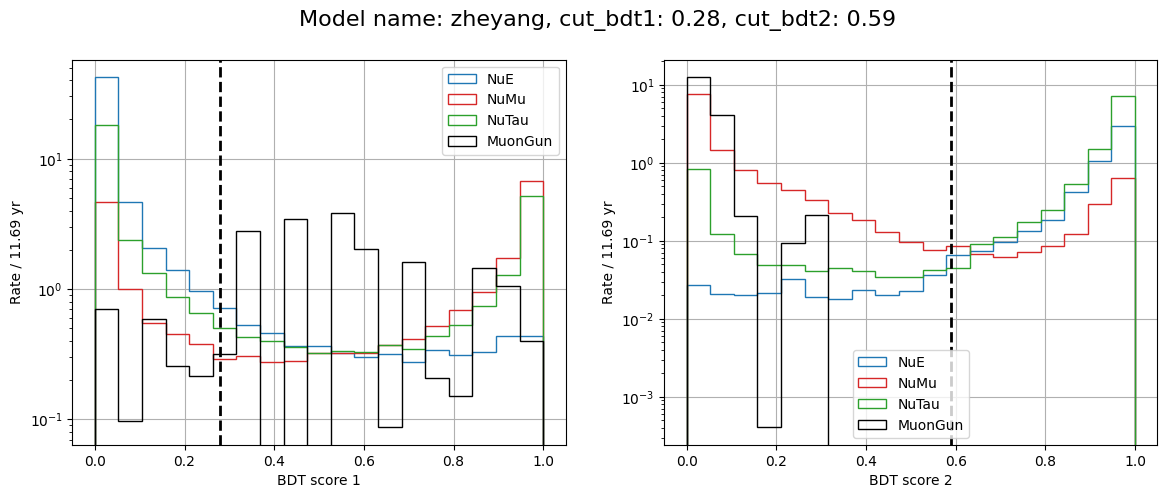

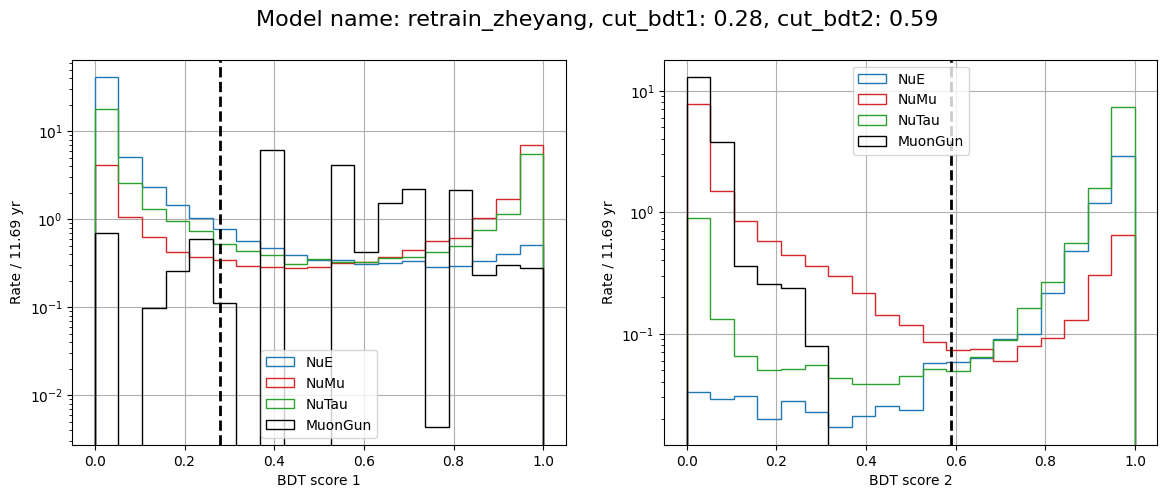

In [ ]:
for model_name in ["zheyang", "retrain_zheyang"]:
    analyze_classification_rates_with_cut(simulation_datasets["taureco_iceprod_v4"], 
                                          classifications["bdt_zheyang_best"], 
                                          model_name=model_name,energy_cut_threshold=None,
                                          print_output=False,
                                          save_output=f"{plotting_path}/general/taureco_iceprod_v4_model-{model_name}_classification-bdt_zheyang_best_energy-None.txt")
    plot_bdt_score( simulation_datasets["taureco_iceprod_v4"], 
                    model_name=model_name, 
                    cut_bdt1=0.28, 
                    cut_bdt2=0.59, 
                    energy_cut_threshold=None,
                    save_output=f"{plotting_path}/general/taureco_iceprod_v4_model-{model_name}_classification-bdt_zheyang_best_energy-None.pdf")

I just randomly check a bdt score cut myself, seems to work pretty well

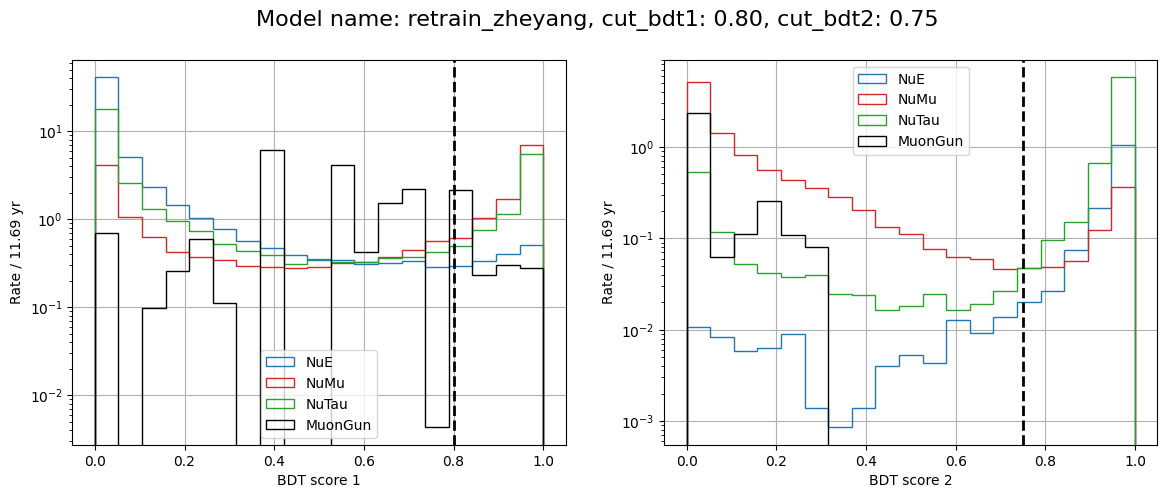

In [55]:
classification = create_bdt_classification( cut_bdt1=0.80, cut_bdt2=0.75 )
analyze_classification_rates_with_cut(simulation_datasets["taureco_iceprod_v4"], 
                                      classification=classification, model_name="retrain_zheyang",energy_cut_threshold=None,
                                      print_output=False,
                                      save_output=f"{plotting_path}/general/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-0.80-bdt2-0.75_energy-None.txt")
plot_bdt_score( simulation_datasets["taureco_iceprod_v4"], 
                model_name="retrain_zheyang", 
                cut_bdt1=0.80, cut_bdt2=0.75, 
                energy_cut_threshold=None,
                save_output=f"{plotting_path}/general/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-0.80-bdt2-0.75_energy-None.pdf")


Now lets do the same cut as before, but including a tau length cut at 10 m. Unfortunately we can't trust too much below 10 m, so it's good to include it. 

If they are double cascade with len < 10 m, i put them as single.

In [58]:
classification = create_bdt_classification_length( cut_bdt1=0.80, cut_bdt2=0.75, cut_length=10 )
_ = analyze_classification_rates_with_cut(simulation_datasets["taureco_iceprod_v4"], classification=classification, 
                                      model_name="retrain_zheyang",energy_cut_threshold=None,
                                      print_output=False,
                                      save_output=f"{plotting_path}/general/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-0.80-bdt2-0.75-length-10_energy-None.txt")

Lets do this in a proper way, just like zheyang does it. I did this before, but lets add a 10 m cut.

In [20]:
from tqdm import tqdm

# n = 50
n = 20
bdt_cuts = np.linspace(0.01,1,n)
model_name = "retrain_zheyang"
energy_cut_threshold = None
simulation_dataset = simulation_datasets["taureco_iceprod_v4"]
cut_length = 10 # m

# Define the cases we want to track
cases = [
    ("Cascade", "NuE"),
    ("Track", "NuMu"),
    ("Double", "NuTau"),
]

# Collect results in a list of dicts
results_list = []

for cut_bdt1 in tqdm(bdt_cuts, desc="BDT1 loop"):
# for cut_bdt1 in bdt_cuts:
    for cut_bdt2 in bdt_cuts:
        classification = create_bdt_classification_length( cut_bdt1=cut_bdt1, cut_bdt2=cut_bdt2, cut_length=cut_length )
        df, purity_df, efficiency_df, significance_df = analyze_classification_rates_with_cut(simulation_dataset=simulation_dataset, 
                                                                                            classification=classification, 
                                                                                            model_name=model_name,
                                                                                            energy_cut_threshold=energy_cut_threshold,
                                                                                            print_output=False)

        # Extract purity for each case and append to results DataFrame
        for event_class, flavor in cases:
            purity     = purity_df.loc[event_class, flavor]
            efficiency = efficiency_df.loc[event_class, flavor]
            significance = significance_df.loc[event_class, flavor]
            results_list.append({
                "cut_bdt1": cut_bdt1,
                "cut_bdt2": cut_bdt2,
                "Class": event_class,
                "Flavor": flavor,
                "Purity": float(purity),
                "Efficiency": float(efficiency),
                "Significance": float(significance),
            })
        
results = pd.DataFrame(results_list)

BDT1 loop:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_4024970/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/rates['total']:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
/tmp/ipykernel_4024970/3131724893.py:146: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/np.sqrt(rates['total']-rates[f]):.2f}" for f in ['NuE', 'NuMu', 'NuTau']
BDT1 loop:   5%|▌         | 1/20 [01:00<19:00, 60.04s/it]/tmp/ipykernel_4024970/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/rates['total']:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
/tmp/ipykernel_4024970/3131724893.py:146: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/np.sqrt(rates['total']-rates[f]):.2f}" for f in ['NuE', 'NuMu', 'NuTau']
BDT1 loop:  10%|█         | 2/20 [01:29<12:41, 42.30s/it]/tmp/ipykernel_4024970/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{

---------- purity 0.71 efficiency 0.14 Significance 3.45
cut_bdt1 0.01 cut_bdt2 0.8436842105263158
---------- purity 0.78 efficiency 0.14 Significance 4.09
cut_bdt1 0.06210526315789474 cut_bdt2 0.6873684210526316
---------- purity 0.85 efficiency 0.13 Significance 4.92
cut_bdt1 0.32263157894736844 cut_bdt2 0.6873684210526316
---------- purity 0.87 efficiency 0.13 Significance 5.37
cut_bdt1 0.16631578947368422 cut_bdt2 0.8436842105263158
---------- purity 0.91 efficiency 0.12 Significance 6.35
cut_bdt1 0.6873684210526316 cut_bdt2 0.8436842105263158


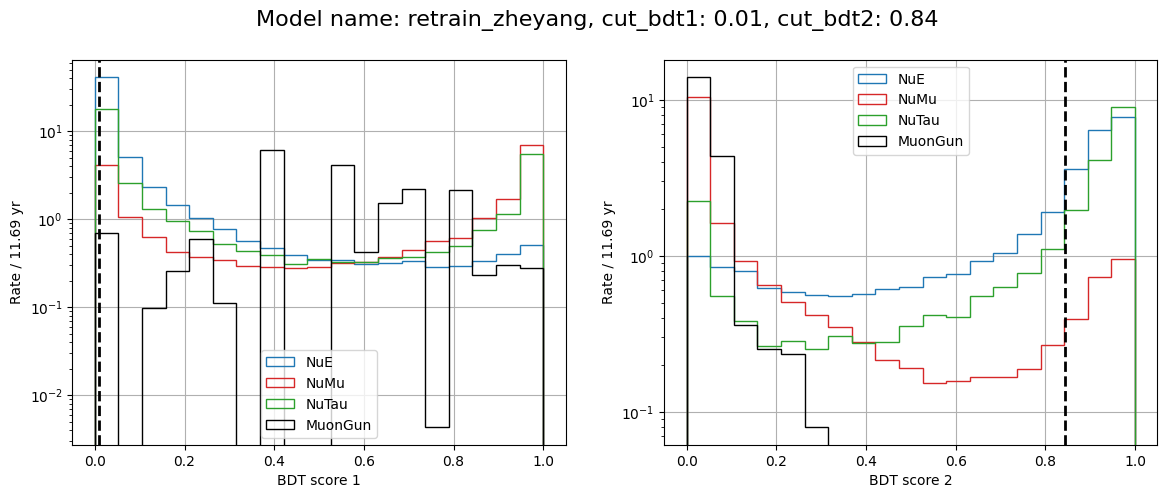

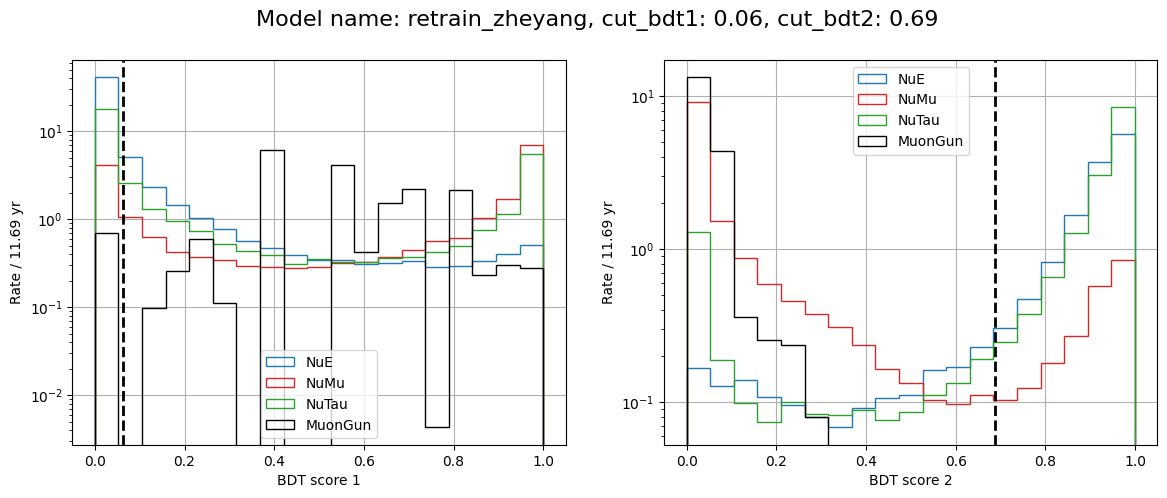

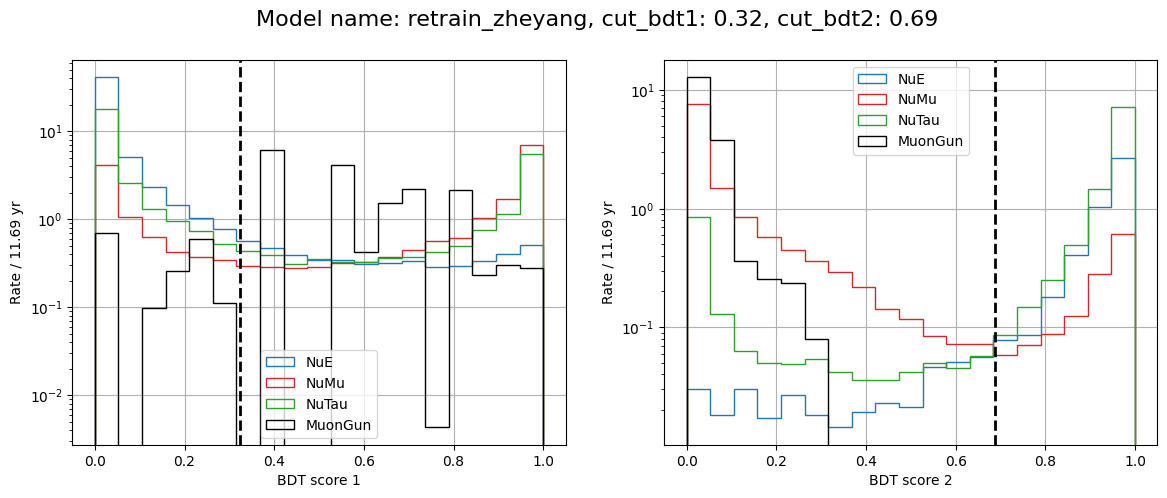

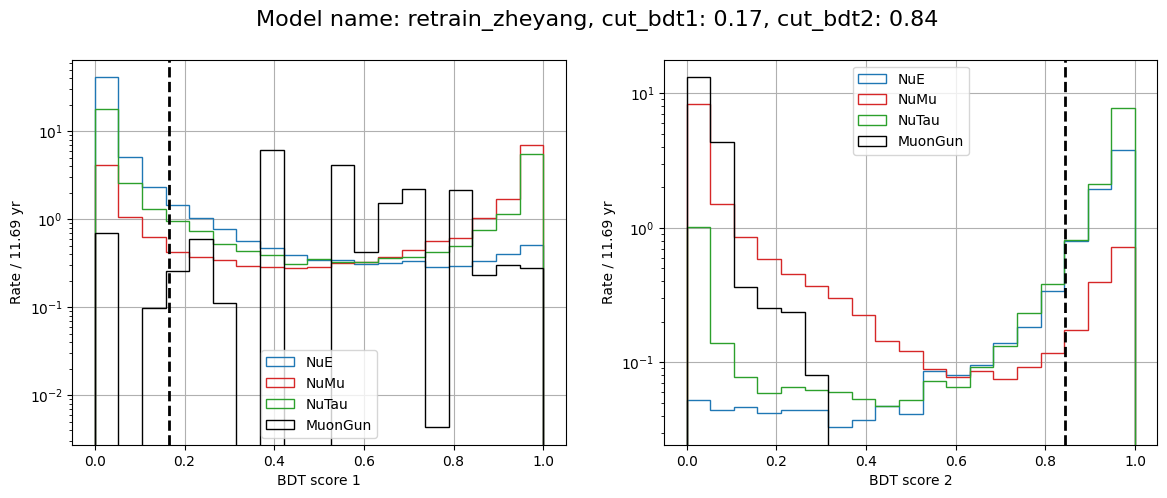

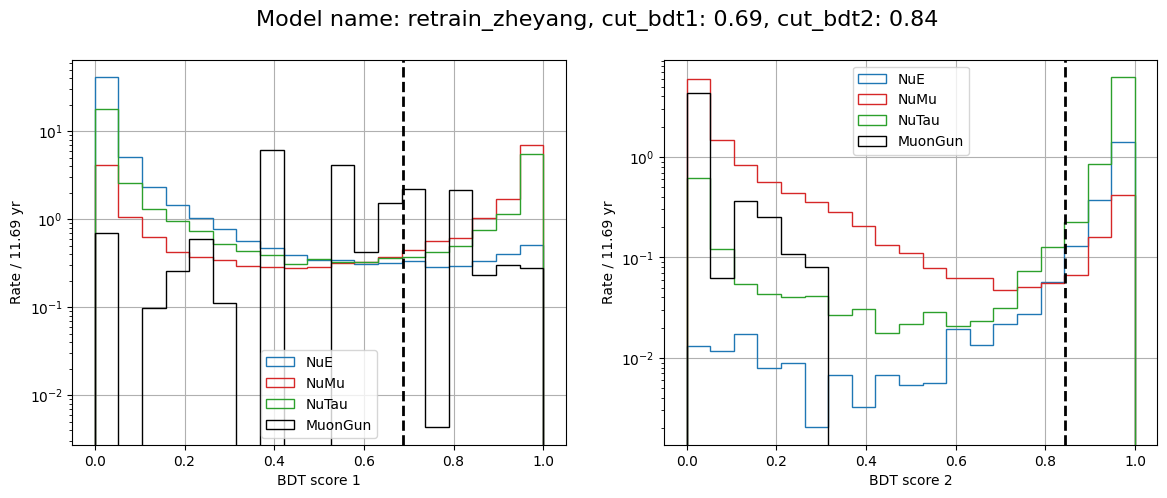

In [23]:
class_opt = "Double"
flavor_opt = "NuTau"

for minimum_purity in [0.7,0.75,0.80,0.85,0.90]:
    results_opt = results[ (results["Class"] == class_opt) & (results["Flavor"] == flavor_opt) & (results["Purity"] > minimum_purity) ].sort_values(by="Efficiency", ascending=False).reset_index(drop=True).iloc[0]

    print(10*"-", "purity",results_opt["Purity"], "efficiency",results_opt["Efficiency"], "Significance", results_opt["Significance"])
    print("cut_bdt1",results_opt["cut_bdt1"], "cut_bdt2",results_opt["cut_bdt2"])

    classification = create_bdt_classification_length( cut_bdt1=results_opt["cut_bdt1"], 
                                                cut_bdt2=results_opt["cut_bdt2"], cut_length=cut_length )
    
    _ = analyze_classification_rates_with_cut(simulation_dataset, 
                                          classification=classification, 
                                          model_name=model_name,
                                          energy_cut_threshold=energy_cut_threshold,
                                          print_output=False,
                                          save_output=f"{plotting_path}/optimise_length-10/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-{results_opt['cut_bdt1']:.2f}-bdt2-{results_opt['cut_bdt2']:.2f}-length-10_energy-{energy_cut_threshold}.txt")
    plot_bdt_score( simulation_dataset, 
                    model_name=model_name,
                    cut_bdt1=results_opt["cut_bdt1"], 
                    cut_bdt2=results_opt["cut_bdt2"], 
                    energy_cut_threshold=energy_cut_threshold,
                    save_output=f"{plotting_path}/optimise_length-10/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-{results_opt['cut_bdt1']:.2f}-bdt2-{results_opt['cut_bdt2']:.2f}-length-10_energy-{energy_cut_threshold}.pdf")


Lets do another optimization, but now with length > 10 m, and Etot > 60 TeV

In [22]:
# n = 50
n = 20
bdt_cuts = np.linspace(0.01,1,n)
model_name = "retrain_zheyang"
energy_cut_threshold = 60e3
simulation_dataset = simulation_datasets["taureco_iceprod_v4"]
cut_length = 10 # m

# Define the cases we want to track
cases = [
    ("Cascade", "NuE"),
    ("Track", "NuMu"),
    ("Double", "NuTau"),
]

# Collect results in a list of dicts
results_list = []

for cut_bdt1 in tqdm(bdt_cuts, desc="BDT1 loop"):
# for cut_bdt1 in bdt_cuts:
    for cut_bdt2 in bdt_cuts:
        classification = create_bdt_classification_length( cut_bdt1=cut_bdt1, cut_bdt2=cut_bdt2, cut_length=cut_length )
        df, purity_df, efficiency_df, significance_df = analyze_classification_rates_with_cut(simulation_dataset=simulation_dataset, 
                                                                                            classification=classification, 
                                                                                            model_name=model_name,
                                                                                            energy_cut_threshold=energy_cut_threshold,
                                                                                            print_output=False)

        # Extract purity for each case and append to results DataFrame
        for event_class, flavor in cases:
            purity     = purity_df.loc[event_class, flavor]
            efficiency = efficiency_df.loc[event_class, flavor]
            significance = significance_df.loc[event_class, flavor]
            results_list.append({
                "cut_bdt1": cut_bdt1,
                "cut_bdt2": cut_bdt2,
                "Class": event_class,
                "Flavor": flavor,
                "Purity": float(purity),
                "Efficiency": float(efficiency),
                "Significance": float(significance),
            })
        
results = pd.DataFrame(results_list)

BDT1 loop:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_2265341/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/rates['total']:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
/tmp/ipykernel_2265341/3131724893.py:146: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/np.sqrt(rates['total']-rates[f]):.2f}" for f in ['NuE', 'NuMu', 'NuTau']
BDT1 loop:   5%|▌         | 1/20 [00:45<14:17, 45.14s/it]/tmp/ipykernel_2265341/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/rates['total']:.2f}" for f in ['NuE', 'NuMu', 'NuTau']
/tmp/ipykernel_2265341/3131724893.py:146: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{rates[f]/np.sqrt(rates['total']-rates[f]):.2f}" for f in ['NuE', 'NuMu', 'NuTau']
BDT1 loop:  10%|█         | 2/20 [01:29<13:21, 44.54s/it]/tmp/ipykernel_2265341/3131724893.py:140: RuntimeWarning: invalid value encountered in scalar divide
  f: f"{

60000.0 10
---------- purity 0.71 efficiency 0.2
cut_bdt1 0.01 cut_bdt2 0.8436842105263158


---------- purity 0.76 efficiency 0.19
cut_bdt1 0.01 cut_bdt2 0.8957894736842106
---------- purity 0.81 efficiency 0.19
cut_bdt1 0.06210526315789474 cut_bdt2 0.791578947368421
---------- purity 0.87 efficiency 0.18
cut_bdt1 0.32263157894736844 cut_bdt2 0.7394736842105263
---------- purity 0.91 efficiency 0.17
cut_bdt1 0.5310526315789474 cut_bdt2 0.8436842105263158


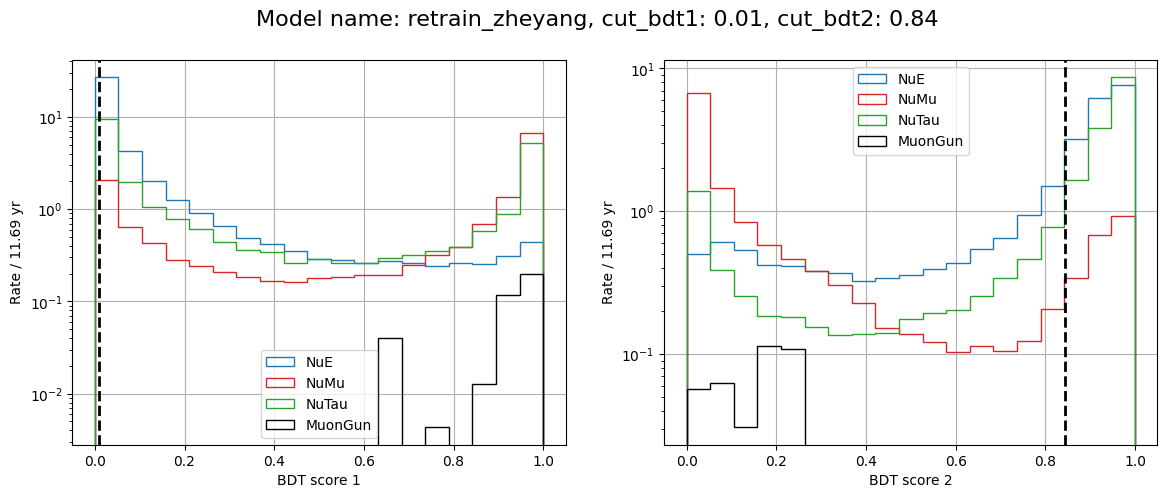

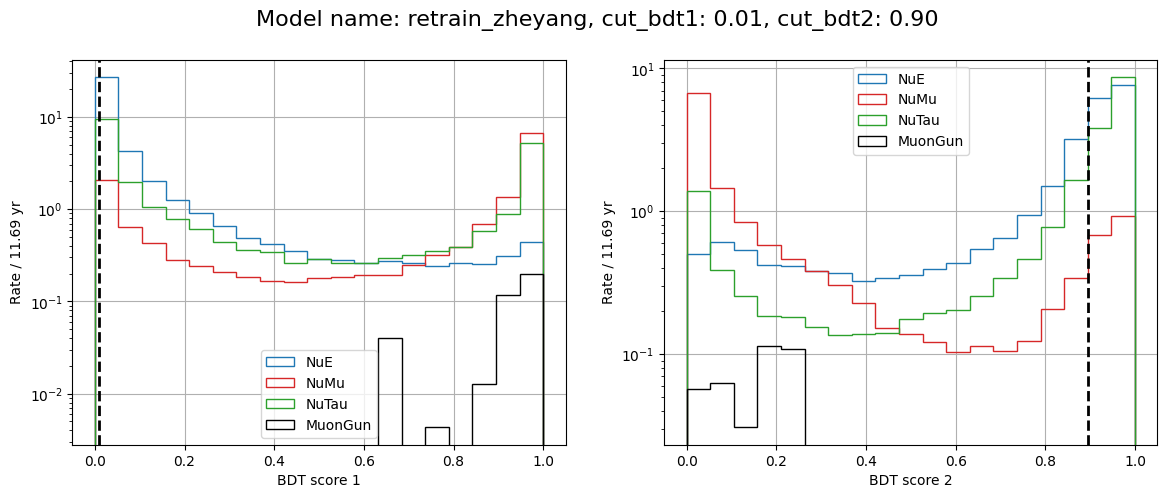

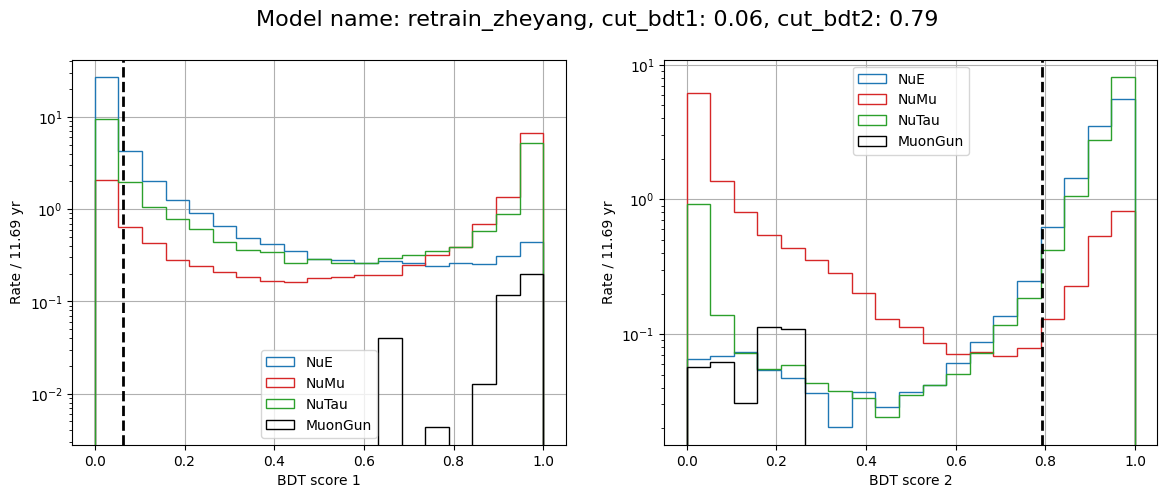

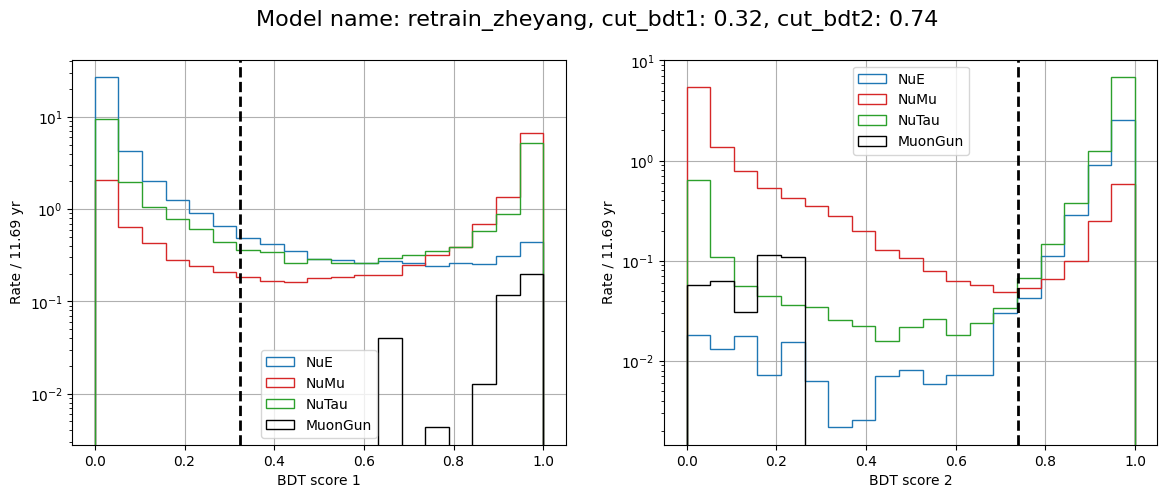

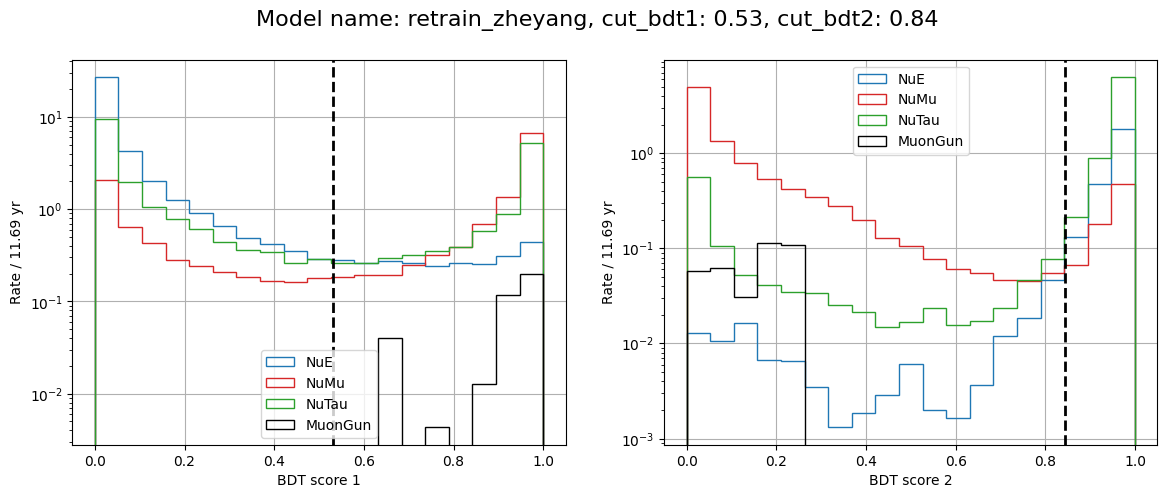

In [25]:
print(energy_cut_threshold, cut_length)

class_opt = "Double"
flavor_opt = "NuTau"

for minimum_purity in [0.7,0.75,0.80,0.85,0.90]:
    results_opt = results[ (results["Class"] == class_opt) & (results["Flavor"] == flavor_opt) & (results["Purity"] > minimum_purity) ].sort_values(by="Efficiency", ascending=False).reset_index(drop=True).iloc[0]

    print(10*"-", "purity",results_opt["Purity"], "efficiency",results_opt["Efficiency"])
    print("cut_bdt1",results_opt["cut_bdt1"], "cut_bdt2",results_opt["cut_bdt2"])

    classification = create_bdt_classification_length( cut_bdt1=results_opt["cut_bdt1"], 
                                                cut_bdt2=results_opt["cut_bdt2"],
                                                 cut_length=cut_length )
    
    _ = analyze_classification_rates_with_cut(simulation_dataset, 
                                          classification=classification, 
                                          model_name=model_name,
                                          energy_cut_threshold=energy_cut_threshold,
                                          print_output=False,
                                          save_output=f"{plotting_path}/optimise_length-10_energy-60e3/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-{results_opt['cut_bdt1']:.2f}-bdt2-{results_opt['cut_bdt2']:.2f}-length-10_energy-{energy_cut_threshold}.txt")
    plot_bdt_score( simulation_dataset, 
                    model_name=model_name,
                    cut_bdt1=results_opt["cut_bdt1"], 
                    cut_bdt2=results_opt["cut_bdt2"], 
                    energy_cut_threshold=energy_cut_threshold,
                    save_output=f"{plotting_path}/optimise_length-10_energy-60e3/taureco_iceprod_v4_model-retrain_zheyang_classification-bdt1-{results_opt['cut_bdt1']:.2f}-bdt2-{results_opt['cut_bdt2']:.2f}-length-10_energy-{energy_cut_threshold}.pdf")


Order by significance

---------- purity 0.94 efficiency 0.07 6.25
cut_bdt1 0.9797959183673469 cut_bdt2 0.9797959183673469

=== Rates ===

            Astro NuE    Astro NuMu   Astro NuTau  Conventional       Prompt
Cascade  56.79 ± 0.55  15.81 ± 0.23  31.25 ± 0.39  23.99 ± 0.98  6.78 ± 0.09
Double    0.06 ± 0.01   0.04 ± 0.01   2.46 ± 0.06   0.01 ± 0.01  0.05 ± 0.00
Track     0.07 ± 0.01   4.75 ± 0.09   1.32 ± 0.05   1.69 ± 0.14  0.24 ± 0.01

=== Purity ===

          NuE  NuMu NuTau
Class                    
Cascade  0.42  0.12  0.23
Double   0.02  0.02  0.94
Track    0.01  0.59  0.16

=== Efficiency ===

          NuE  NuMu NuTau
Class                    
Cascade  1.00  0.77  0.89
Double   0.00  0.00  0.07
Track    0.00  0.23  0.04

=== Sig / sqrt(bg) ===

          NuE  NuMu NuTau
Class                    
Cascade  6.44  1.45  3.07
Double   0.04  0.03  6.25
Track    0.03  2.60  0.51

=== Rates ===

\begin{tabular}{lccccc}
\toprule
 & Astro NuE & Astro NuMu & Astro NuTau & Conventional & Prompt \\
\midrul

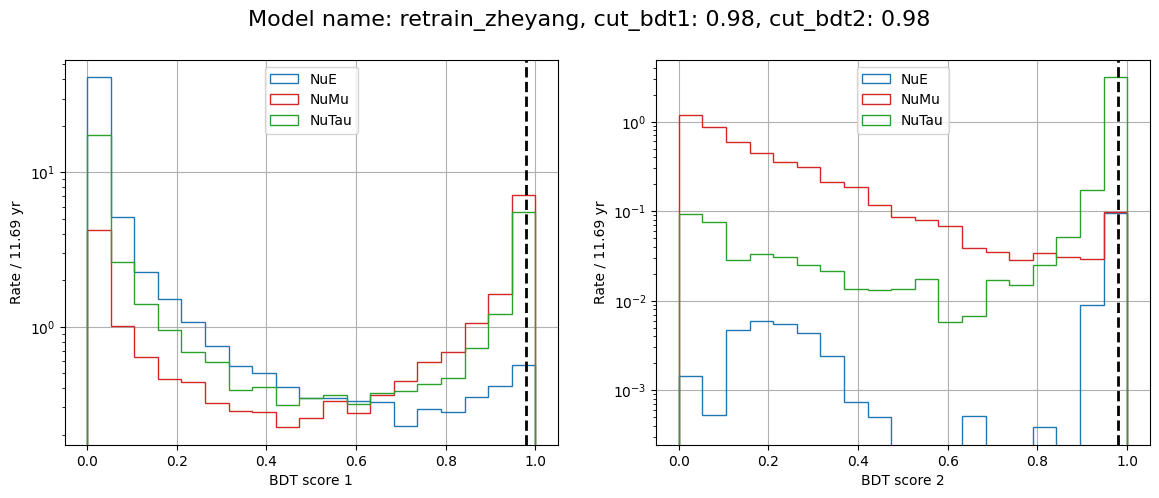

In [32]:
class_opt = "Double"
flavor_opt = "NuTau"

results_opt = results[ (results["Class"] == class_opt) & (results["Flavor"] == flavor_opt) ].sort_values(by="Significance", ascending=False).reset_index(drop=True).iloc[0:5]

results_opt = results_opt.iloc[0]

print(10*"-", "purity",results_opt["Purity"], "efficiency",results_opt["Efficiency"],results_opt["Significance"])
print("cut_bdt1",results_opt["cut_bdt1"], "cut_bdt2",results_opt["cut_bdt2"])

classification = create_bdt_classification( cut_bdt1=results_opt["cut_bdt1"], 
                                            cut_bdt2=results_opt["cut_bdt2"] )

analyze_classification_rates_with_cut(simulation_dataset, 
                                        classification=classification, 
                                        model_name=model_name,
                                        energy_cut_threshold=None)
plot_bdt_score( simulation_dataset, 
                model_name=model_name,
                cut_bdt1=results_opt["cut_bdt1"], 
                cut_bdt2=results_opt["cut_bdt2"], 
                energy_cut_threshold=energy_cut_threshold,
                savename="optimised" )

plot a bdt score without a cut

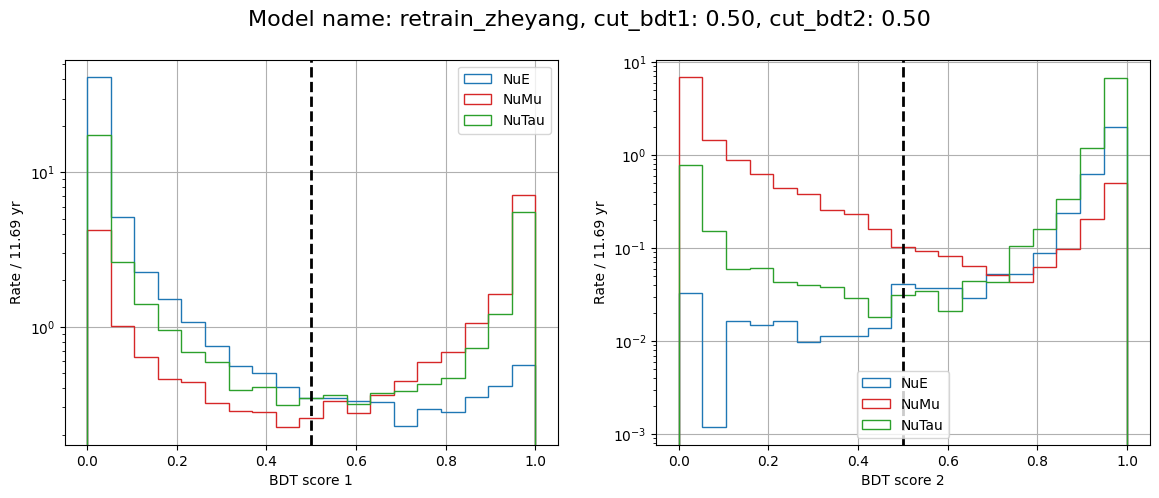

In [20]:
plot_bdt_score( simulation_dataset, 
                model_name="retrain_zheyang",
                cut_bdt1=0.5, 
                cut_bdt2=0.5, 
                energy_cut_threshold=None,
                savename="nocuts" )